<a href="https://colab.research.google.com/github/M16artz/Base-de-datos/blob/main/HC_12Queens_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏔️ Análisis de Complejidad: Algoritmo Hill Climbing
## Caso de Estudio: Problema de las 12 Reinas
### Asignatura: Complejidad Computacional

---

**Estructura del notebook:**
1. Representación del estado y función heurística
2. Generación de vecinos (Steepest-Ascent)
3. Algoritmo Hill Climbing completo
4. Análisis de complejidad empírico
5. Problema de óptimos locales y Random Restart
6. Visualizaciones de complejidad y convergencia

---

## 📦 Instalación de dependencias

In [2]:
# Instalación de dependencias (solo necesario en Colab)
!pip install matplotlib numpy seaborn scipy -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import time
import random
from scipy.optimize import curve_fit
from collections import Counter

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

print('✅ Librerías cargadas correctamente.')
print(f'   NumPy {np.__version__}')

✅ Librerías cargadas correctamente.
   NumPy 2.0.2


---
## SECCIÓN 1 — Representación del Estado y Función Heurística

### Representación por columnas
El estado es un vector `q` de longitud `n` donde `q[i]` es la fila de la reina en la columna `i`.
Esto garantiza implícitamente que **no hay conflictos por columna**.

### Función heurística h(q)
Cuenta los **pares de reinas que se atacan**:
```
h(q) = #{(i,j) : i < j  AND  (q[i]==q[j]  OR  |i-j|==|q[i]-q[j]|)}
```

SECCIÓN 1: Estado inicial y función heurística
n = 12 reinas
Estado inicial: [8, 0, 2, 1, 3, 7, 5, 9, 10, 4, 11, 6]
Conflictos h(q) = 8
Comparaciones realizadas: 66
Esperado C(n,2) = 66
¿Coincide? True

→ Complejidad de h(q) completa: O(n²) = O(12²) = 144 operaciones
→ Con deltas: O(1) por movimiento evaluado (ver construir_auxiliares)

→ Verificación arreglos auxiliares (conflictos via arrays): 8 ≈ 8


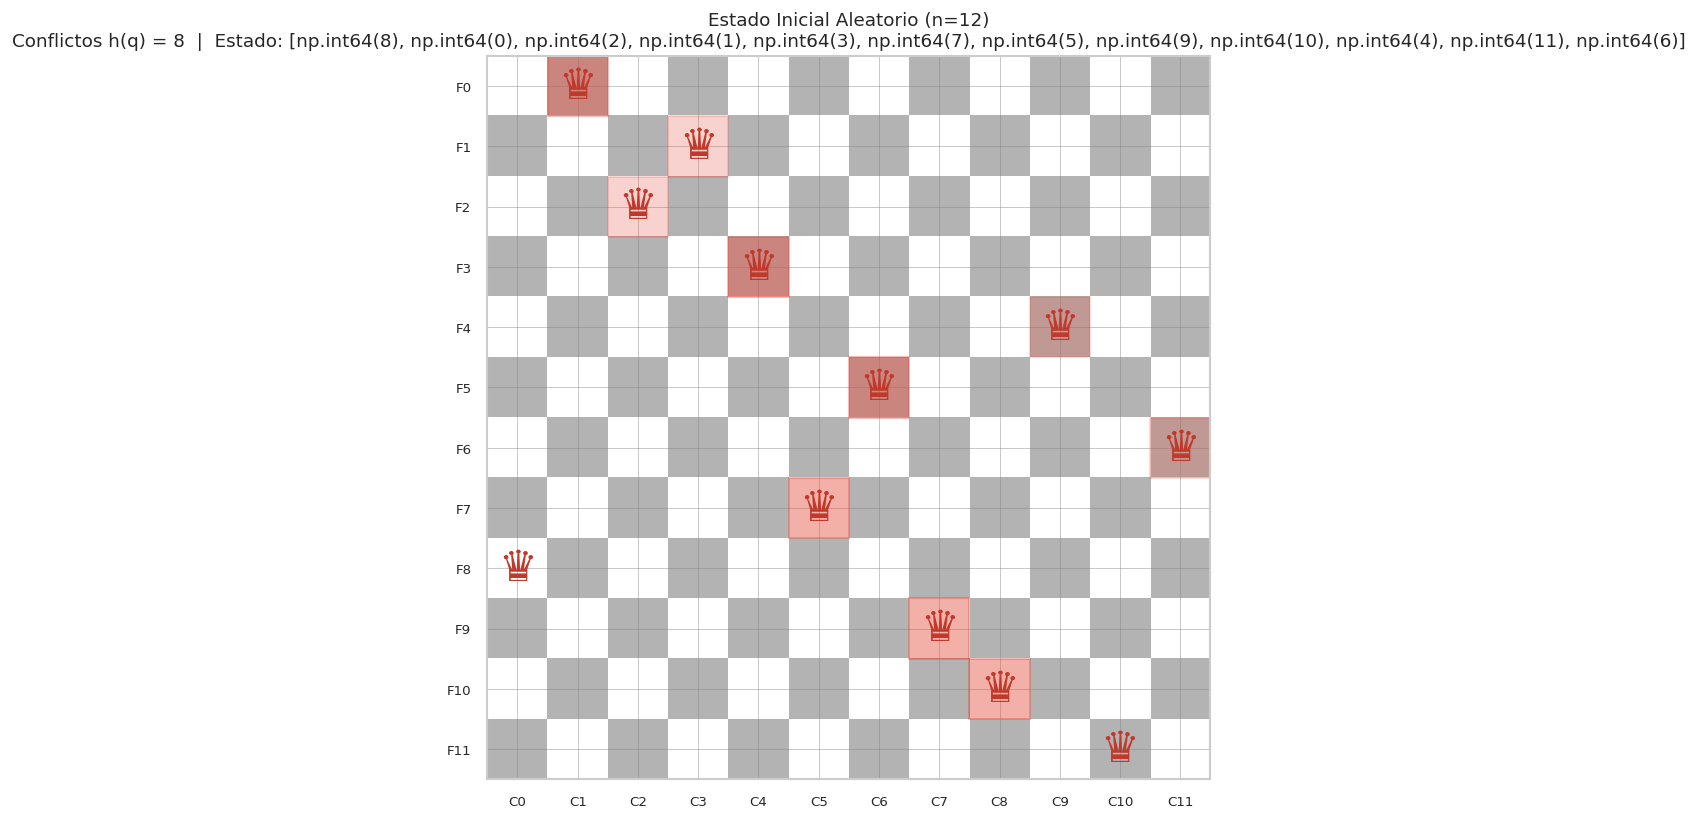

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 1: Representación del Estado y Función Heurística
# ══════════════════════════════════════════════════════════════════════════════

def generar_estado_inicial(n):
    """
    Genera un estado inicial aleatorio mediante permutación.
    Estado: lista de longitud n donde estado[i] = fila de reina en columna i.
    Usar permutación garantiza que no hay conflictos de fila al inicio.
    Complejidad espacial: O(n)
    """
    return list(np.random.permutation(n))


def calcular_conflictos(estado):
    """
    Calcula el número de pares de reinas en conflicto.
    Dos reinas (i, q[i]) y (j, q[j]) se atacan si:
      - Misma fila:     q[i] == q[j]
      - Misma diagonal: |i - j| == |q[i] - q[j]|
    """
    n = len(estado)
    conflictos = 0
    comparaciones = 0

    for i in range(n):
        for j in range(i + 1, n):
            comparaciones += 1
            if estado[i] == estado[j]:
                conflictos += 1
            elif abs(i - j) == abs(estado[i] - estado[j]):
                conflictos += 1

    return conflictos, comparaciones


def calcular_conflictos_simple(estado):
    """Versión sin contador de comparaciones (para uso interno del algoritmo)."""
    n = len(estado)
    conflictos = 0
    for i in range(n):
        for j in range(i + 1, n):
            if estado[i] == estado[j] or abs(i - j) == abs(estado[i] - estado[j]):
                conflictos += 1
    return conflictos


# ─────────────────────────────────────────────────────────────────────────────
# ESTRUCTURAS AUXILIARES PARA EVALUACIÓN POR DELTAS — O(1) por movimiento
# (Paper Sección IV-B, técnica "costo de evaluación por deltas")
# ─────────────────────────────────────────────────────────────────────────────

def construir_auxiliares(estado):
    """
    Construye arreglos auxiliares que cuentan cuántas reinas hay en cada:
      - fila
      - diagonal principal (col - fila)
      - diagonal secundaria (col + fila)

    Con esto, calcular el DELTA de conflictos al mover una reina es O(1),
    ya que solo se consultan/actualizan estas tres estructuras.

    Complejidad: O(n) para construir.
    Espacio: O(n) — tres arreglos de tamaño 2n-1 / n.
    """
    n = len(estado)
    filas     = [0] * n
    diag_pri  = [0] * (2 * n - 1)   # índice: col - fila + (n-1)
    diag_sec  = [0] * (2 * n - 1)   # índice: col + fila

    for col, fila in enumerate(estado):
        filas[fila]                    += 1
        diag_pri[col - fila + (n - 1)] += 1
        diag_sec[col + fila]           += 1

    return filas, diag_pri, diag_sec


def conflictos_reina(col, fila, n, filas, diag_pri, diag_sec):
    """
    Cuenta cuántos conflictos genera la reina en (col, fila)
    con las demás reinas ya registradas en los arreglos auxiliares.
    Cada array tiene el conteo INCLUYENDO la reina misma, por eso se resta 1.

    Complejidad: O(1) — solo tres consultas de array.
    """
    c  = filas[fila]                    - 1   # conflictos de fila
    c += diag_pri[col - fila + (n - 1)] - 1   # conflictos diagonal principal
    c += diag_sec[col + fila]           - 1   # conflictos diagonal secundaria
    return c


def calcular_delta(estado, col, fila_nueva, filas, diag_pri, diag_sec):
    """
    Calcula el DELTA de conflictos al mover la reina de 'col'
    desde su fila actual a 'fila_nueva'.

    delta > 0 → la posición nueva tiene MÁS conflictos (peor)
    delta < 0 → la posición nueva tiene MENOS conflictos (mejor)
    delta = 0 → igual número de conflictos

    Pasos:
      1. Quitar la reina de su posición actual de los arreglos → O(1)
      2. Medir conflictos en destino → O(1)
      3. Restaurar la reina en posición original → O(1)
      4. Medir conflictos en origen → O(1)
      => Total: O(1) por movimiento evaluado
    """
    n = len(estado)
    fila_actual = estado[col]

    # 1. Remover la reina de su posición actual
    filas[fila_actual]                          -= 1
    diag_pri[col - fila_actual + (n - 1)]       -= 1
    diag_sec[col + fila_actual]                 -= 1

    # --- CORRECCIÓN: Añadir reina a nueva posición antes de medir ---
    filas[fila_nueva]                           += 1
    diag_pri[col - fila_nueva + (n - 1)]        += 1
    diag_sec[col + fila_nueva]                  += 1

    # 2. Conflictos que causaría en la nueva posición (ahora es exacto)
    c_nueva = conflictos_reina(col, fila_nueva, n, filas, diag_pri, diag_sec)

    # --- CORRECCIÓN: Retirar la reina de la nueva posición ---
    filas[fila_nueva]                           -= 1
    diag_pri[col - fila_nueva + (n - 1)]        -= 1
    diag_sec[col + fila_nueva]                  -= 1

    # 3. Restaurar la reina a su posición original
    filas[fila_actual]                          += 1
    diag_pri[col - fila_actual + (n - 1)]       += 1
    diag_sec[col + fila_actual]                 += 1

    # 4. Conflictos que causa actualmente
    c_actual = conflictos_reina(col, fila_actual, n, filas, diag_pri, diag_sec)

    return c_nueva - c_actual

def visualizar_tablero(estado, titulo='Estado del tablero'):
    """Visualiza el tablero de ajedrez con las reinas y sus líneas de ataque."""
    n = len(estado)
    tablero = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            tablero[i][j] = (i + j) % 2

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(tablero, cmap='Greys', vmin=0, vmax=1, alpha=0.3)

    conflictos, _ = calcular_conflictos(estado)

    # Marcar celdas en conflicto
    for i in range(n):
        for j in range(i + 1, n):
            en_conf = (estado[i] == estado[j] or
                       abs(i - j) == abs(estado[i] - estado[j]))
            if en_conf:
                ax.add_patch(plt.Rectangle((i - 0.5, estado[i] - 0.5), 1, 1,
                                           color='#e74c3c', alpha=0.25))
                ax.add_patch(plt.Rectangle((j - 0.5, estado[j] - 0.5), 1, 1,
                                           color='#e74c3c', alpha=0.25))

    for col, fila in enumerate(estado):
        ax.text(col, fila, '♛', ha='center', va='center',
                fontsize=26, color='#c0392b', fontweight='bold')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'C{i}' for i in range(n)], fontsize=8)
    ax.set_yticklabels([f'F{i}' for i in range(n)], fontsize=8)
    estado_str = str(estado) if n <= 12 else f"[{', '.join(map(str,estado[:6]))}...]"
    ax.set_title(f'{titulo}\nConflictos h(q) = {conflictos}  |  Estado: {estado_str}', fontsize=11)
    ax.grid(True, linewidth=0.5, color='gray', alpha=0.5)
    plt.tight_layout()
    plt.show()


# ─── Demostración ─────────────────────────────────────────────────────────────
n = 12
estado_demo = generar_estado_inicial(n)
conf, comps = calcular_conflictos(estado_demo)

print('=' * 60)
print('SECCIÓN 1: Estado inicial y función heurística')
print('=' * 60)
print(f'n = {n} reinas')
estado_list = [int(x) for x in estado_demo]
print(f"Estado inicial: {estado_list}")
print(f'Conflictos h(q) = {conf}')
print(f'Comparaciones realizadas: {comps}')
print(f'Esperado C(n,2) = {n*(n-1)//2}')
print(f'¿Coincide? {comps == n*(n-1)//2}')
print(f'\n→ Complejidad de h(q) completa: O(n²) = O({n}²) = {n**2} operaciones')
print(f'→ Con deltas: O(1) por movimiento evaluado (ver construir_auxiliares)')

# Verificar que los arreglos auxiliares son correctos
filas_a, dp_a, ds_a = construir_auxiliares(estado_demo)
conflictos_delta = sum(
    max(0, conflictos_reina(col, estado_demo[col], n, filas_a, dp_a, ds_a))
    for col in range(n)
) // 2
print(f'\n→ Verificación arreglos auxiliares (conflictos via arrays): {conflictos_delta} ≈ {conf}')

visualizar_tablero(estado_demo, 'Estado Inicial Aleatorio (n=12)')


---
## SECCIÓN 2 — Generación de Vecinos

Para cada columna `i`, la reina puede moverse a cualquiera de las `n-1` filas alternativas.

**Número total de vecinos:**
```
V = n × (n-1)  ==>  Para n=12: V = 12 × 11 = 132
```

**Complejidad de generar vecinos:** O(n²) = Θ(n²)

SECCIÓN 2: Generación de vecinos con evaluación por deltas
n = 12
Vecinos generados (V):  132
Esperado n(n-1) = 132
¿Coincide? True

Evaluación por deltas:
  Operaciones O(1) aplicadas: 132  (= V = 132)
  Mejor movimiento → conflictos = 7

Costo por iteración (Paper Tabla I):
  V × C = 132 × 1 = 132 operaciones  [O(n²)]
  (vs 132 × 66 = 8,712 con evaluación completa [O(n⁴)])


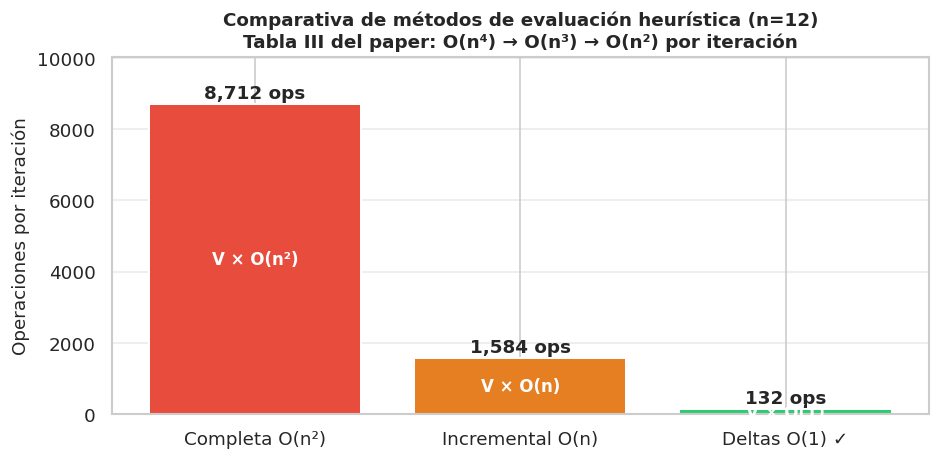

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2: Generación de Vecinos (Steepest-Ascent con evaluación por Deltas)
# ══════════════════════════════════════════════════════════════════════════════

def generar_vecinos(estado):
    """
    Genera TODOS los vecinos del estado actual (Steepest-Ascent).
    Un vecino = mover UNA reina a otra fila dentro de su columna.
    """
    n = len(estado)
    vecinos = []
    for col in range(n):
        for fila in range(n):
            if fila != estado[col]:
                vecino = list(estado)
                vecino[col] = fila
                vecinos.append((col, fila, vecino))   # guardamos col/fila para audit
    return vecinos


def generar_mejor_vecino_deltas(estado):
    """
    Genera todos los vecinos y devuelve el de MENOR número de conflictos,
    usando la técnica de evaluación por DELTAS descrita en el paper (Sec. IV-B).
    """
    n = len(estado)
    filas_a, dp_a, ds_a = construir_auxiliares(estado)   # O(n) — una sola vez
    conf_actual = calcular_conflictos_simple(estado)

    mejor_delta   = float('inf')
    mejor_col     = None
    mejor_fila    = None
    ops_delta     = 0   # contador de operaciones O(1) aplicadas

    for col in range(n):           # n iteraciones
        for fila in range(n):      # n iteraciones
            if fila != estado[col]:
                delta = calcular_delta(estado, col, fila, filas_a, dp_a, ds_a)  # O(1)
                ops_delta += 1
                if delta < mejor_delta:
                    mejor_delta = delta
                    mejor_col   = col
                    mejor_fila  = fila

    mejor_vecino = list(estado)
    if mejor_col is not None:
        mejor_vecino[mejor_col] = mejor_fila

    return mejor_vecino, conf_actual + mejor_delta, ops_delta


# ─── Demostración comparativa: O(n²) completo vs O(1) deltas ─────────────────
n = 12
estado_demo = generar_estado_inicial(n)

# Método clásico O(n²) por evaluación
vecinos_raw = generar_vecinos(estado_demo)
V_contado = len(vecinos_raw)

# Método con deltas O(1) por evaluación
mejor_v_d, conf_d, ops_d = generar_mejor_vecino_deltas(estado_demo)

print('=' * 65)
print('SECCIÓN 2: Generación de vecinos con evaluación por deltas')
print('=' * 65)
print(f'n = {n}')
print(f'Vecinos generados (V):  {V_contado}')
print(f'Esperado n(n-1) = {n*(n-1)}')
print(f'¿Coincide? {V_contado == n*(n-1)}')
print()
print(f'Evaluación por deltas:')
print(f'  Operaciones O(1) aplicadas: {ops_d}  (= V = {V_contado})')
print(f'  Mejor movimiento → conflictos = {conf_d}')
print()
print(f'Costo por iteración (Paper Tabla I):')
print(f'  V × C = {V_contado} × 1 = {V_contado} operaciones  [O(n²)]')
print(f'  (vs {V_contado} × {n*(n-1)//2} = {V_contado*n*(n-1)//2:,} con evaluación completa [O(n⁴)])')

# Comparativa visual de operaciones
metodos = ['Completa O(n²)', 'Incremental O(n)', 'Deltas O(1) ✓']
ops_iter = [V_contado * n*(n-1)//2,   V_contado * n,   V_contado * 1]
colores  = ['#e74c3c', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metodos, ops_iter, color=colores, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, ops_iter):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,} ops', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Operaciones por iteración', fontsize=11)
ax.set_title(f'Comparativa de métodos de evaluación heurística (n={n})\n'
             f'Tabla III del paper: O(n⁴) → O(n³) → O(n²) por iteración',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, max(ops_iter) * 1.15)
ax.grid(True, axis='y', alpha=0.4)

# Añadir etiqueta de complejidad
for bar, label in zip(bars, ['V × O(n²)', 'V × O(n)', 'V × O(1)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            label, ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


---
## SECCIÓN 3 — Algoritmo Hill Climbing Completo

### Fórmula de complejidad:
```
T(n) = O(I × V × C)
```
donde, usando evaluación por **deltas** (Sección IV-B del paper):
- **I** = O(n) iteraciones hasta convergencia (≤ n pasos máximo)
- **V** = n(n-1) = O(n²) vecinos por estado
- **C** = **O(1)** costo de evaluación mediante deltas

➜ **Complejidad total: O(n³)** — Para n=12: O(12 × 132 × 1) = O(1,584 ops)

> Comparación (Paper Tabla III):
> | Método           | C         | Costo/iter |
> |------------------|-----------|------------|
> | Completa         | O(n²)=66  | O(n⁴)=8712 |
> | Incremental      | O(n)=12   | O(n³)=1584 |
> | **Deltas ✓**     | **O(1)=1**| **O(n²)=132** |


SECCIÓN 3: Ejecución HC con deltas (O(n³) total) para n=12
  Estado inicial: h = 8
  Iter   1: h = 7  (132 ops-delta)
  Iter   2: h = 5  (132 ops-delta)
  Iter   3: h = 4  (132 ops-delta)
  Iter   4: h = 3  (132 ops-delta)
  Iter   5: h = 2  (132 ops-delta)
  Iter   6: h = 2  (132 ops-delta)
  → Óptimo local tras 6 iteraciones

──── RESULTADO ────

n (reinas)            : 12
Estado final (lista)  : [3, 0, 6, 4, 9, 1, 5, 2, 10, 3, 7, 11]
Estado (columna:fila) : 0:3, 1:0, 2:6, 3:4, 4:9, 5:1, 6:5, 7:2, 8:10, 9:3, 10:7, 11:11
Conflictos finales    : 2
Iteraciones (I)       : 6
Es solución exacta    : False
Ops-delta totales     : 792
  = I × V = 6 × 132 = 792
Tiempo de ejecución   : 0.00184 segundos (1.84 ms)

── Verificación Tabla I del paper ──
  I = 6  iteraciones (≤ n = 12 → O(n) ✓)
  V = n(n-1) = 132  vecinos    (O(n²) ✓)
  C = O(1) = 1              (delta ✓)
  T(12) = I×V×C = 6×132×1 = 792 ops  → O(n³) = O(1728) ✓


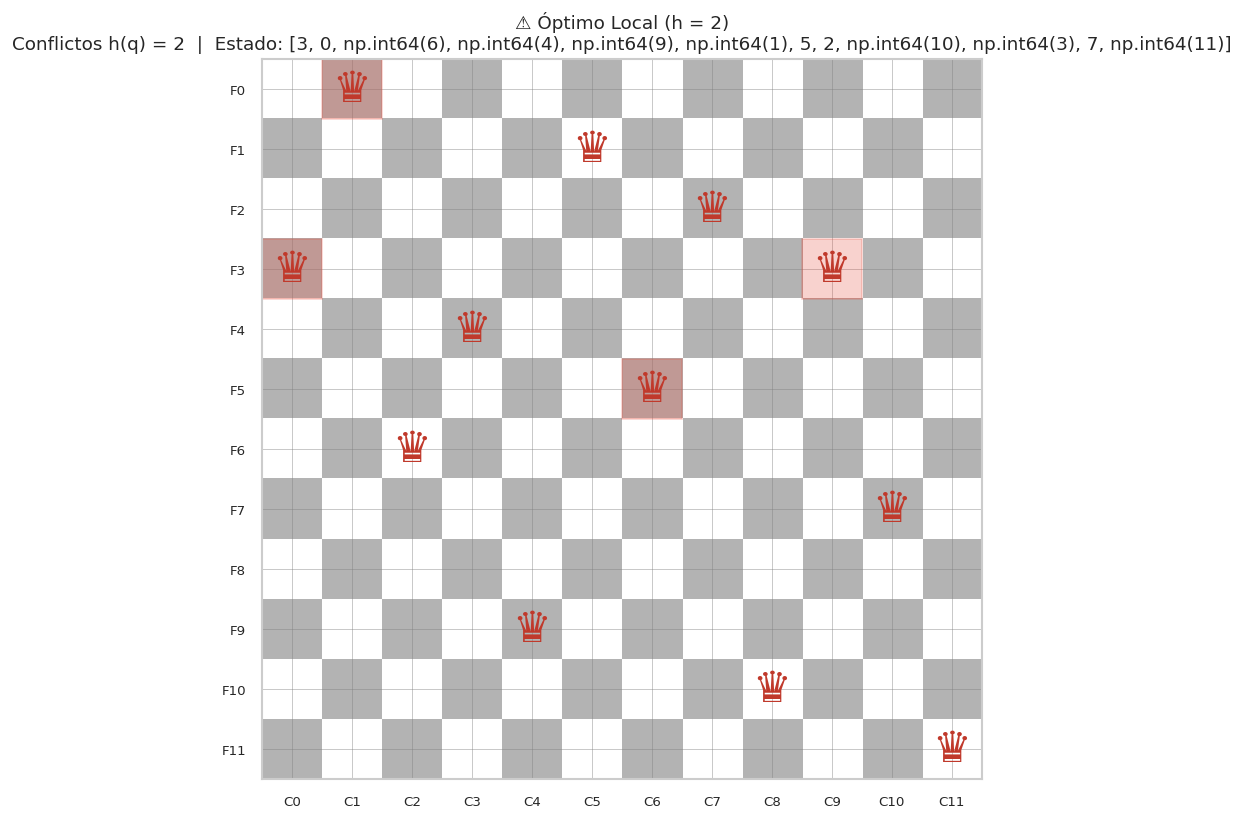

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3: Algoritmo Hill Climbing Steepest-Ascent con evaluación por DELTAS
# Complejidad total: O(I × n² × 1) = O(n³)
# ══════════════════════════════════════════════════════════════════════════════
from tabulate import tabulate
import numpy as np
import math
import time  # <--- 1. NUEVO: Importar la librería de tiempo

def to_pylist(arr):
    return [int(x) for x in arr]

def estado_pairs(estado):
    return ', '.join(f"{c}:{r}" for c, r in enumerate(to_pylist(estado)))

def pretty_number(x):
    return f"{x:,}"

def print_header(title, width=65):
    print('=' * width)
    print(title)
    print('=' * width)

def hill_climbing(n=12, estado_inicial=None, verbose=False):
    """
    Algoritmo Hill Climbing Steepest-Ascent — Problema de las N-Reinas.
    Usa evaluación por DELTAS para lograr C = O(1) por movimiento evaluado.
    """

    # <--- 2. NUEVO: Iniciar el cronómetro justo al empezar el algoritmo
    t_inicio = time.perf_counter()

    if estado_inicial is None:
        actual = generar_estado_inicial(n)
    else:
        actual = list(estado_inicial)

    conflictos_actual  = calcular_conflictos_simple(actual)
    historial          = [conflictos_actual]
    iteraciones        = 0
    operaciones_totales = 0

    if verbose:
        print(f'  Estado inicial: h = {conflictos_actual}')

    while conflictos_actual > 0:
        iteraciones += 1

        mejor_vecino, mejor_conflictos, ops = generar_mejor_vecino_deltas(actual)
        operaciones_totales += ops

        if verbose:
            print(f'  Iter {iteraciones:3d}: h = {mejor_conflictos}  ({ops} ops-delta)')

        if mejor_conflictos < conflictos_actual:
            actual            = mejor_vecino
            conflictos_actual = mejor_conflictos
            historial.append(conflictos_actual)
        else:
            if verbose:
                print(f'  → Óptimo local tras {iteraciones} iteraciones')
            break

    # <--- 3. NUEVO: Detener el cronómetro y calcular la diferencia
    t_fin = time.perf_counter()
    tiempo_total = t_fin - t_inicio

    return {
        'estado_final'       : actual,
        'conflictos'         : conflictos_actual,
        'iteraciones'        : iteraciones,
        'es_solucion'        : conflictos_actual == 0,
        'historial'          : historial,
        'operaciones_totales': operaciones_totales,
        'tiempo_ejecucion'   : tiempo_total  # <--- 4. NUEVO: Añadirlo al diccionario de retorno
    }


# ─── Demostración ─────────────────────────────────────────────────────────────
print_header('SECCIÓN 3: Ejecución HC con deltas (O(n³) total) para n=12')

resultado = hill_climbing(n=12, verbose=True)
n = 12
estado_final = to_pylist(resultado['estado_final'])
conf = resultado['conflictos']
I = resultado['iteraciones']
ops = resultado['operaciones_totales']
tiempo = resultado['tiempo_ejecucion'] # <--- 5. NUEVO: Extraer el tiempo

print('\n──── RESULTADO ────\n')
print(f'n (reinas)            : {n}')
print(f'Estado final (lista)  : {estado_final}')
print(f'Estado (columna:fila) : {estado_pairs(estado_final)}')
print(f'Conflictos finales    : {conf}')
print(f'Iteraciones (I)       : {I}')
print(f'Es solución exacta    : {resultado["es_solucion"]}')
print(f'Ops-delta totales     : {pretty_number(ops)}')
print(f'  = I × V = {I} × {n*(n-1)} = {pretty_number(I * n * (n-1))}')

# <--- 6. NUEVO: Imprimir el tiempo formateado en segundos y milisegundos
print(f'Tiempo de ejecución   : {tiempo:.5f} segundos ({tiempo * 1000:.2f} ms)')

# Paper Tabla I verificación
I_real = resultado["iteraciones"]
V = n * (n - 1)   # 132
C = 1             # O(1) por delta
print(f'\n── Verificación Tabla I del paper ──')
print(f'  I = {I_real}  iteraciones (≤ n = {n} → O(n) ✓)')
print(f'  V = n(n-1) = {V}  vecinos    (O(n²) ✓)')
print(f'  C = O(1) = {C}              (delta ✓)')
print(f'  T(12) = I×V×C = {I_real}×{V}×{C} = {I_real*V*C:,} ops  → O(n³) = O({n**3}) ✓')

if resultado['es_solucion']:
    visualizar_tablero(resultado['estado_final'], '✅ Solución Exacta Encontrada (h = 0)')
else:
    visualizar_tablero(resultado['estado_final'],
                       f'⚠️ Óptimo Local (h = {resultado["conflictos"]})')

---
## SECCIÓN 4 — Análisis de Complejidad Empírico

Medimos el tiempo de ejecución para distintos valores de `n` y ajustamos la curva `O(n⁴)`.


SECCIÓN 4: Tiempos de ejecución — Verificación O(n³) con deltas
   n |   V=n(n-1) |   Ops/iter |   T/iter(ms) |   T_total(ms)
------------------------------------------------------------
   4 |         12 |         12 |       0.0593 |        0.0617
   6 |         30 |         30 |       0.1033 |        0.2222
   8 |         56 |         56 |       0.1549 |        0.5241
  10 |         90 |         90 |       0.2095 |        0.7391
  12 |        132 |        132 |       0.2984 |        1.3255
  14 |        182 |        182 |       0.4909 |        1.6038
  16 |        240 |        240 |       0.5247 |        3.0921
  18 |        306 |        306 |       0.6672 |        4.3224
  20 |        380 |        380 |       0.8035 |        5.4883


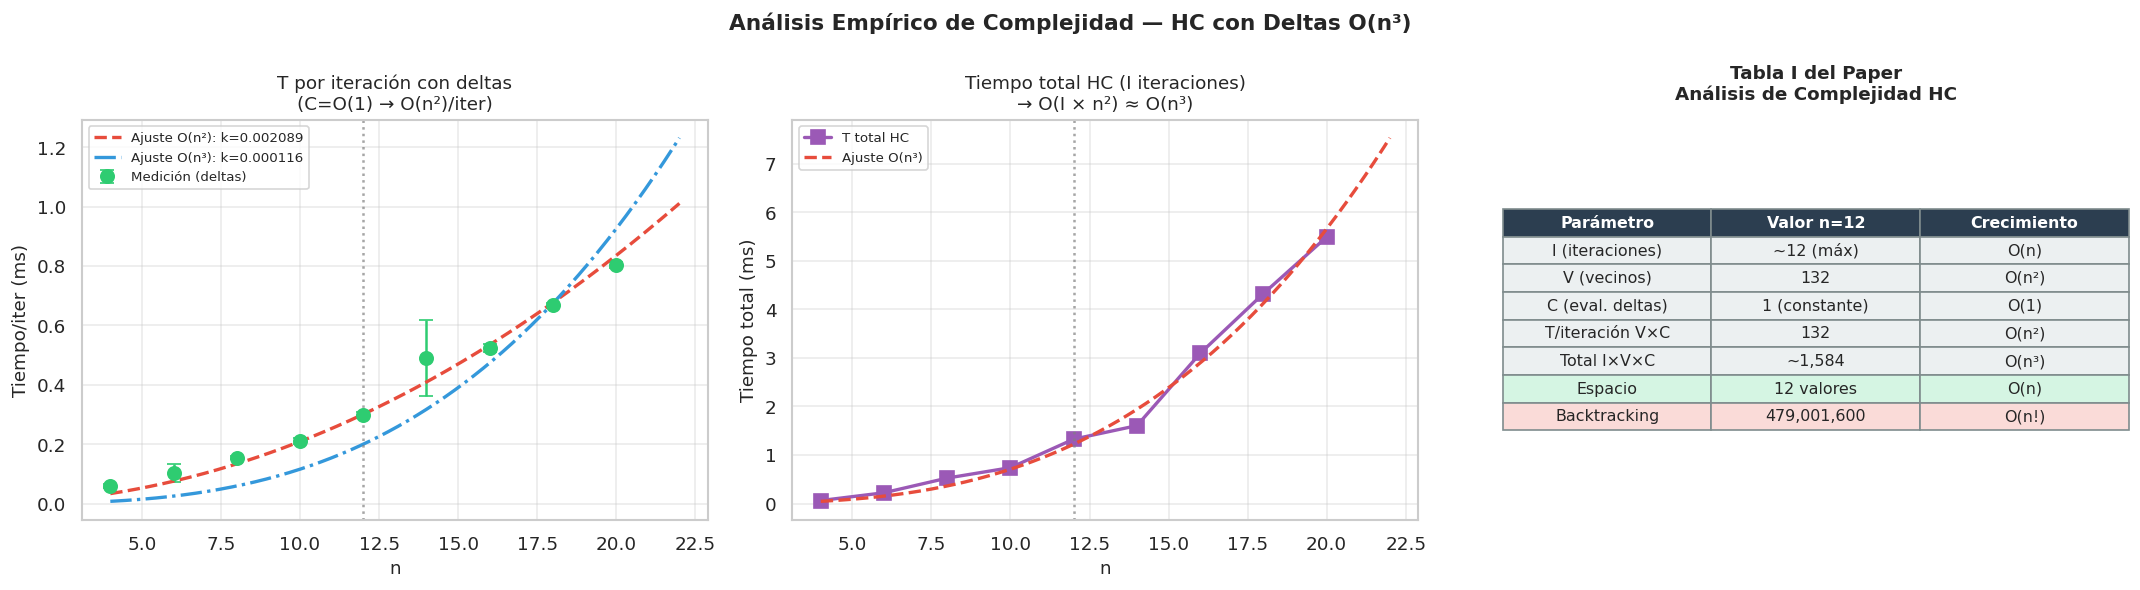


→ La evaluación por deltas reduce la complejidad por iteración:
  O(n⁴) → O(n³) → O(n²)  (Tabla III del paper)
  Complejidad total: O(I × n²) ≈ O(n × n²) = O(n³) ✓


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4: Análisis de Complejidad Empírico — O(n³) con deltas
# ══════════════════════════════════════════════════════════════════════════════

def medir_costo_por_iteracion(n, repeticiones=10):
    """
    Mide el tiempo promedio de UNA iteración de HC con deltas para tamaño n.
    Esto corresponde a medir O(V × C) = O(n² × 1) = O(n²) por iteración.
    El total O(n³) incluye las ~n iteraciones.
    """
    tiempos = []
    for _ in range(repeticiones):
        estado = generar_estado_inicial(n)
        t0 = time.perf_counter()
        generar_mejor_vecino_deltas(estado)
        t1 = time.perf_counter()
        tiempos.append(t1 - t0)
    return np.mean(tiempos), np.std(tiempos)


def medir_tiempo_total_hc(n, repeticiones=15):
    """Mide el tiempo total de UNA corrida HC completa para tamaño n."""
    tiempos = []
    for _ in range(repeticiones):
        estado = generar_estado_inicial(n)
        t0 = time.perf_counter()
        hill_climbing(n=n, estado_inicial=estado)
        t1 = time.perf_counter()
        tiempos.append(t1 - t0)
    return np.mean(tiempos) * 1000, np.std(tiempos) * 1000   # ms


valores_n = [4, 6, 8, 10, 12, 14, 16, 18, 20]

print('=' * 70)
print('SECCIÓN 4: Tiempos de ejecución — Verificación O(n³) con deltas')
print('=' * 70)
print(f'{"n":>4} | {"V=n(n-1)":>10} | {"Ops/iter":>10} | {"T/iter(ms)":>12} | {"T_total(ms)":>13}')
print('-' * 60)

tiempos_iter   = []
tiempos_total  = []
tiempos_std    = []
costos_teoricos = []

for n_val in valores_n:
    V   = n_val * (n_val - 1)
    ops = V * 1   # C = O(1)
    t_i, t_i_std = medir_costo_por_iteracion(n_val, repeticiones=8)
    t_t, _       = medir_tiempo_total_hc(n_val, repeticiones=8)
    tiempos_iter.append(t_i * 1000)
    tiempos_total.append(t_t)
    tiempos_std.append(t_i_std * 1000)
    costos_teoricos.append(ops)
    print(f'{n_val:>4} | {V:>10} | {ops:>10,} | {t_i*1000:>12.4f} | {t_t:>13.4f}')

# ─── Ajuste de curvas ─────────────────────────────────────────────────────────
def modelo_n3(n, k): return k * n**3
def modelo_n2(n, k): return k * n**2

n_arr  = np.array(valores_n, dtype=float)
t_arr  = np.array(tiempos_iter)
tt_arr = np.array(tiempos_total)

params3, _ = curve_fit(modelo_n3, n_arr, t_arr)
params2, _ = curve_fit(modelo_n2, n_arr, t_arr)
params3t, _ = curve_fit(modelo_n3, n_arr, tt_arr)

# ─── Figura 1: Tiempo por iteración ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n_smooth = np.linspace(4, 22, 300)

ax = axes[0]
ax.errorbar(valores_n, tiempos_iter, yerr=tiempos_std,
            fmt='o', color='#2ecc71', markersize=8, capsize=4, label='Medición (deltas)')
ax.plot(n_smooth, modelo_n2(n_smooth, params2[0]),
        '--', color='#e74c3c', lw=2, label=f'Ajuste O(n²): k={params2[0]:.6f}')
ax.plot(n_smooth, modelo_n3(n_smooth, params3[0]),
        '-.', color='#3498db', lw=2, label=f'Ajuste O(n³): k={params3[0]:.6f}')
ax.axvline(x=12, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('n', fontsize=11); ax.set_ylabel('Tiempo/iter (ms)', fontsize=11)
ax.set_title('T por iteración con deltas\n(C=O(1) → O(n²)/iter)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

# ─── Figura 2: Tiempo total ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(valores_n, tiempos_total, 's-', color='#9b59b6',
        markersize=8, lw=2, label='T total HC')
ax.plot(n_smooth, modelo_n3(n_smooth, params3t[0]),
        '--', color='#e74c3c', lw=2, label=f'Ajuste O(n³)')
ax.axvline(x=12, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('n', fontsize=11); ax.set_ylabel('Tiempo total (ms)', fontsize=11)
ax.set_title('Tiempo total HC (I iteraciones)\n→ O(I × n²) ≈ O(n³)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

# ─── Figura 3: Tabla de complejidades — Paper Tabla I ─────────────────────────
ax = axes[2]
ax.axis('off')

tabla_data = [
    ['Parámetro',        'Valor n=12',   'Crecimiento'],
    ['I (iteraciones)',  '~12 (máx)',    'O(n)'],
    ['V (vecinos)',      '132',           'O(n²)'],
    ['C (eval. deltas)', '1 (constante)','O(1)'],
    ['T/iteración V×C',  '132',           'O(n²)'],
    ['Total I×V×C',      '~1,584',        'O(n³)'],
    ['Espacio',          '12 valores',    'O(n)'],
    ['Backtracking',     '479,001,600',   'O(n!)'],
]

colors_tab = [['#2c3e50','#2c3e50','#2c3e50']] +              [['#ecf0f1','#ecf0f1','#ecf0f1']] * 5 +              [['#d5f5e3','#d5f5e3','#d5f5e3']] +              [['#fadbd8','#fadbd8','#fadbd8']]

tbl = ax.table(cellText=tabla_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(colors_tab[row][col])
    cell.set_edgecolor('#7f8c8d')
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')

ax.set_title('Tabla I del Paper\nAnálisis de Complejidad HC', fontsize=11, fontweight='bold', pad=12)

plt.suptitle('Análisis Empírico de Complejidad — HC con Deltas O(n³)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n→ La evaluación por deltas reduce la complejidad por iteración:')
print(f'  O(n⁴) → O(n³) → O(n²)  (Tabla III del paper)')
print(f'  Complejidad total: O(I × n²) ≈ O(n × n²) = O(n³) ✓')


---
## SECCIÓN 5 — Óptimos Locales y Random Restart

HC sin reinicio frecuentemente queda atrapado en un **óptimo local** (h > 0).

**Estrategia:** Random Restart HC — ejecutar HC `R` veces desde estados iniciales
distintos y reportar el mejor resultado.

**Teorema (Jacobson y Yücesan [1]):** Para todo algoritmo HC que no visita el óptimo
en probabilidad, existe una macro-iteración k₀ a partir de la cual Random Restart domina:
```
P{(B_RR(k))^c} ≥ P{(B_HC(k))^c}  para todo k ≥ k₀
```

SECCIÓN 5: Experimento con 500 corridas HC (n=12)
Soluciones exactas encontradas: 17 / 500
Tasa de éxito HC puro: 3.4%
Iteraciones: media=4.57, mediana=5.0, máx=9
Conflictos finales: mín=0, media=2.13

Calculando tasa de éxito vs reinicios (puede tardar ~30s)...


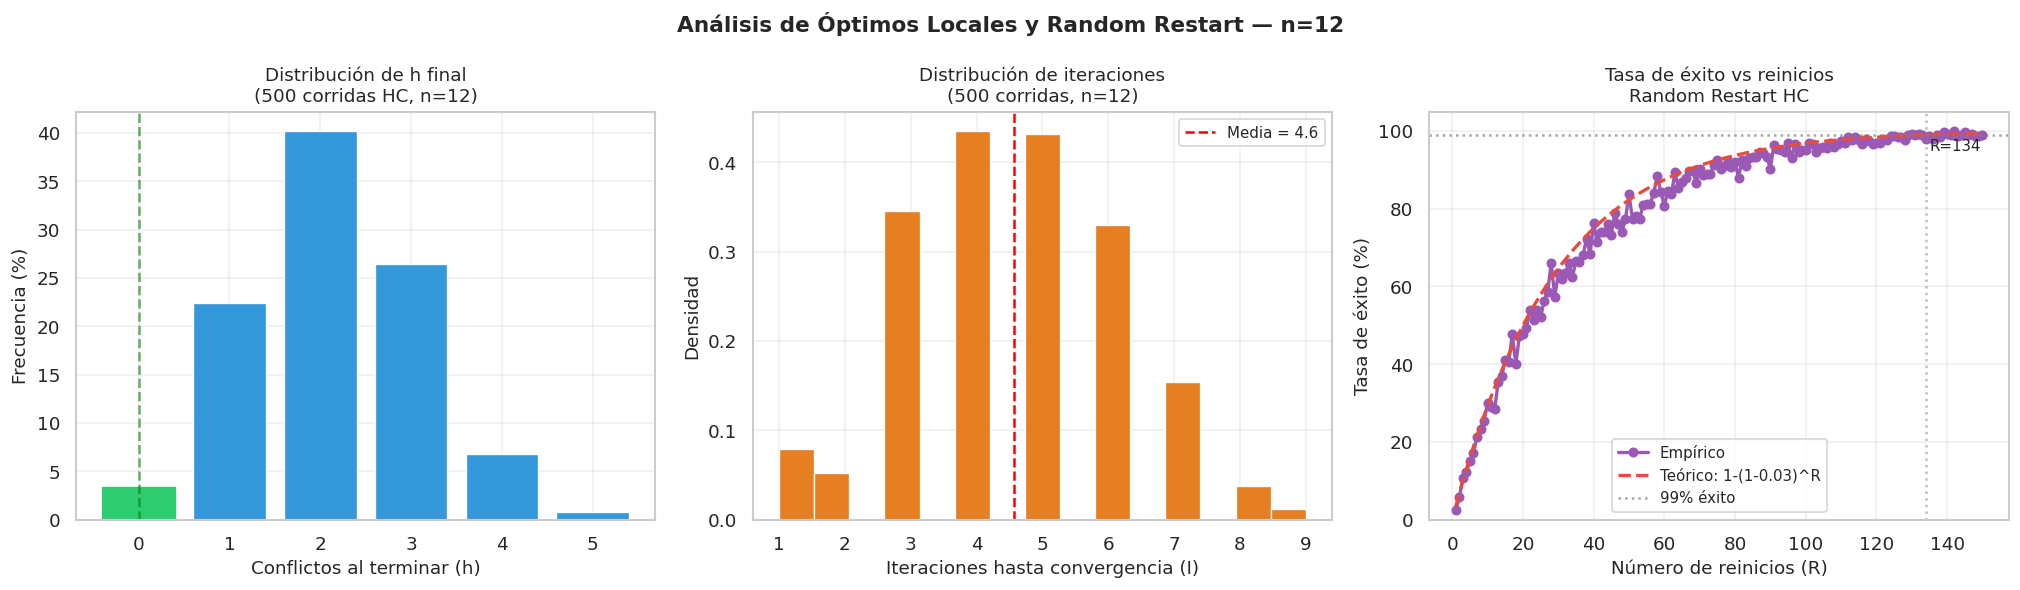


→ Con R reinicios, la probabilidad teórica de éxito es:
  P(éxito | R) = 1 - (1 - 0.034)^R
  Esto corresponde a Random Restart HC con costo O(R × I × n⁴).


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5: Óptimos Locales, Mesetas y Random Restart
# ══════════════════════════════════════════════════════════════════════════════

def random_restart_hc(n=12, max_reinicios=100):
    """
    Random Restart Hill Climbing.

    Ejecuta HC desde R estados iniciales aleatorios.
    Complejidad: O(R × I × V × C) = O(R × I × n⁴)

    Referencia: [1] Jacobson y Yücesan (2004), Teoremas 2 y 3.
                [4] Magrini (2022) aplica esta estrategia para estimación MLE.
    """
    mejor_resultado = None
    mejor_conflictos = float('inf')
    reinicios_hasta_exito = None

    for r in range(1, max_reinicios + 1):
        resultado = hill_climbing(n=n)

        if resultado['conflictos'] < mejor_conflictos:
            mejor_conflictos = resultado['conflictos']
            mejor_resultado = resultado

        if mejor_conflictos == 0 and reinicios_hasta_exito is None:
            reinicios_hasta_exito = r
            break  # Solución exacta encontrada

    return mejor_resultado, reinicios_hasta_exito


# ─── Experimento: 500 corridas de HC puro para n=12 ───────────────────────────
N_EXPERIMENTOS = 500
n = 12

print('=' * 60)
print(f'SECCIÓN 5: Experimento con {N_EXPERIMENTOS} corridas HC (n={n})')
print('=' * 60)

resultados_bulk = [hill_climbing(n=n) for _ in range(N_EXPERIMENTOS)]

soluciones     = [r for r in resultados_bulk if r['es_solucion']]
tasa_exito     = len(soluciones) / N_EXPERIMENTOS * 100
iters_todos    = [r['iteraciones'] for r in resultados_bulk]
confs_finales  = [r['conflictos'] for r in resultados_bulk]

print(f'Soluciones exactas encontradas: {len(soluciones)} / {N_EXPERIMENTOS}')
print(f'Tasa de éxito HC puro: {tasa_exito:.1f}%')
print(f'Iteraciones: media={np.mean(iters_todos):.2f}, '
      f'mediana={np.median(iters_todos):.1f}, '
      f'máx={max(iters_todos)}')
print(f'Conflictos finales: mín={min(confs_finales)}, '
      f'media={np.mean(confs_finales):.2f}')

# ─── Experimento: tasa de éxito vs número de reinicios ────────────────────────
MAX_R = 150
N_REPS_RR = 300

print(f'\nCalculando tasa de éxito vs reinicios (puede tardar ~30s)...')
tasas_rr = []
for R in range(1, MAX_R + 1):
    exitos = 0
    for _ in range(N_REPS_RR):
        for _ in range(R):
            res = hill_climbing(n=n)
            if res['es_solucion']:
                exitos += 1
                break
    tasas_rr.append(exitos / N_REPS_RR * 100)

# Curva teórica: P(éxito con R reinicios) = 1 - (1 - p)^R
p_est = tasa_exito / 100
teorica = [100 * (1 - (1 - p_est)**R) for R in range(1, MAX_R + 1)]

# ─── Gráficas ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfica 1: Distribución de conflictos finales
ax = axes[0]
contador_confs = Counter(confs_finales)
x_vals = sorted(contador_confs.keys())
y_vals = [contador_confs[x] / N_EXPERIMENTOS * 100 for x in x_vals]
bars = ax.bar(x_vals, y_vals, color='#3498db', edgecolor='white', linewidth=0.8)
bars[0].set_color('#2ecc71') if 0 in x_vals else None  # Verde para h=0
ax.set_xlabel('Conflictos al terminar (h)', fontsize=11)
ax.set_ylabel('Frecuencia (%)', fontsize=11)
ax.set_title(f'Distribución de h final\n({N_EXPERIMENTOS} corridas HC, n={n})', fontsize=11)
ax.axvline(x=0, color='green', linestyle='--', alpha=0.6)
ax.grid(True, alpha=0.3)

# Gráfica 2: Distribución de iteraciones
ax = axes[1]
ax.hist(iters_todos, bins=15, color='#e67e22', edgecolor='white',
        linewidth=0.8, density=True)
ax.axvline(np.mean(iters_todos), color='red', linestyle='--',
           label=f'Media = {np.mean(iters_todos):.1f}')
ax.set_xlabel('Iteraciones hasta convergencia (I)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title(f'Distribución de iteraciones\n({N_EXPERIMENTOS} corridas, n={n})', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Gráfica 3: Tasa de éxito vs reinicios
ax = axes[2]
R_vals = list(range(1, MAX_R + 1))
ax.plot(R_vals, tasas_rr, 'o-', color='#9b59b6', linewidth=2,
        markersize=5, label='Empírico')
ax.plot(R_vals, teorica, '--', color='#e74c3c', linewidth=2,
        label=f'Teórico: 1-(1-{p_est:.2f})^R')
ax.axhline(y=99, color='gray', linestyle=':', alpha=0.7, label='99% éxito')
# Marcar el R para alcanzar 99%
for R, t in enumerate(teorica, 1):
    if t >= 99:
        ax.axvline(x=R, color='gray', linestyle=':', alpha=0.5)
        ax.annotate(f'R={R}', xy=(R, 99), xytext=(R+1, 95), fontsize=9)
        break
ax.set_xlabel('Número de reinicios (R)', fontsize=11)
ax.set_ylabel('Tasa de éxito (%)', fontsize=11)
ax.set_title('Tasa de éxito vs reinicios\nRandom Restart HC', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.suptitle('Análisis de Óptimos Locales y Random Restart — n=12', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n→ Con R reinicios, la probabilidad teórica de éxito es:')
print(f'  P(éxito | R) = 1 - (1 - {p_est:.3f})^R')
print(f'  Esto corresponde a Random Restart HC con costo O(R × I × n⁴).')

---
## SECCIÓN 6 — Visualización de Convergencia y Resumen de Complejidades

Muestra el historial de convergencia de HC y la comparación de notaciones asintóticas.

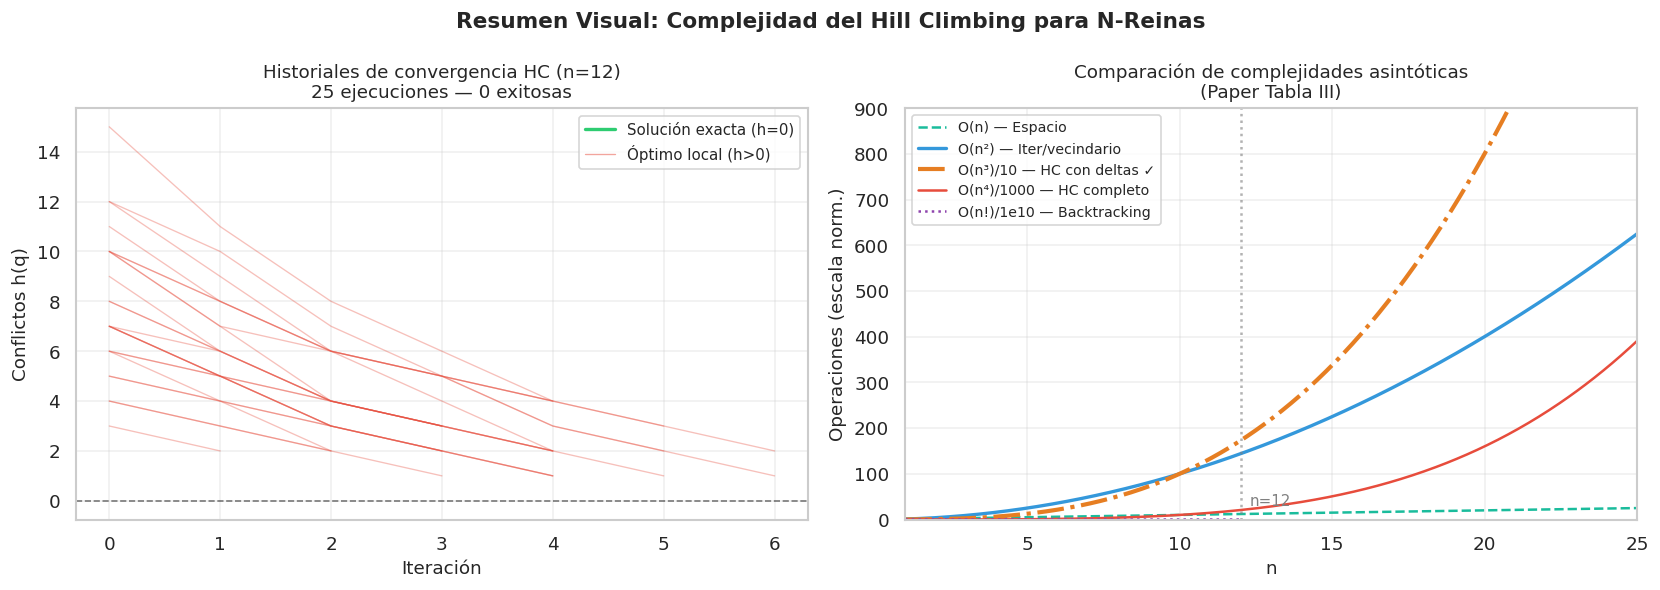


Buscando solución exacta con reinicio aleatorio...
✅ Solución exacta en intento #6


/tmp/ipykernel_1478/1732331391.py:183: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


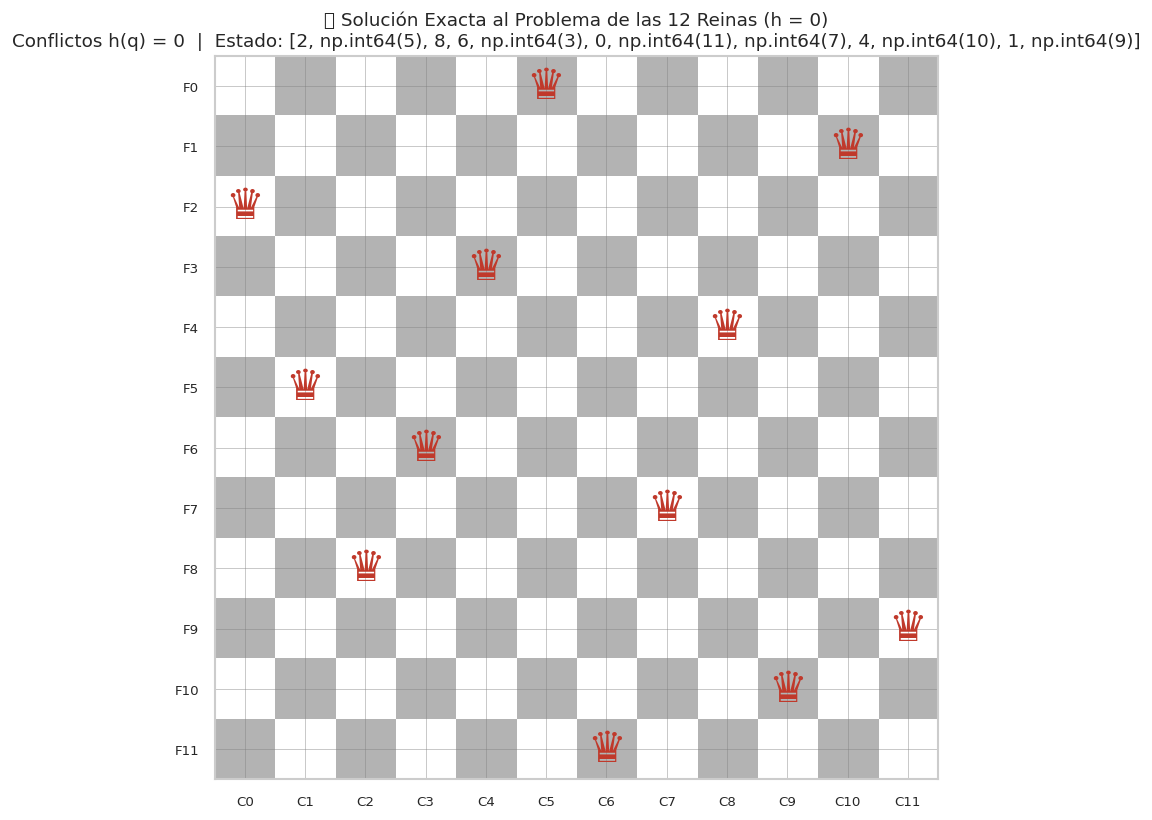


TABLA III — RESUMEN DE COMPLEJIDADES HC STEEPEST-ASCENT (n=12)
  Operacion                           Notacion   n=12                 Caso
------------------------------------------------------------------------
  Generación de sucesores             O(n²)      132 vecinos          Peor caso/iter
  Eval. heurística (completa)         O(n²)      66 comparaciones     Por estado
  Eval. heurística (increm.)          O(n)       12 operaciones       Por estado
  Eval. heurística (deltas) ✓         O(1)       1 operación          Por estado
  Costo total/iter (deltas)           O(n²)      132 ops              Peor caso
  Complejidad temporal total          O(n³)      ~1,584 ops           O(I×V×C)
  Complejidad espacial                O(n)       12 valores           Constante
  Backtracking exhaustivo             O(n!)      479,001,600          Referencia

✅ Fórmula T(n) = O(I × V × C) verificada:
   I ≤ n     = 12  → O(n)
   V = n(n-1)= 132  → O(n²)
   C (deltas)= 1    → O(1)
   ─────────────

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6: Visualizaciones Finales — Convergencia, Complejidades y Resumen
# ══════════════════════════════════════════════════════════════════════════════

# ─── 6A: Historiales de convergencia HC ──────────────────────────────────────
import math
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
N_TRAZAS = 25
exitos_vis = 0
for i in range(N_TRAZAS):
    res = hill_climbing(n=12)
    color = '#2ecc71' if res['es_solucion'] else '#e74c3c'
    lw    = 2.2 if res['es_solucion'] else 0.8
    alpha = 0.9 if res['es_solucion'] else 0.35
    ax.plot(res['historial'], color=color, linewidth=lw, alpha=alpha)
    if res['es_solucion']: exitos_vis += 1

from matplotlib.lines import Line2D
leyenda = [Line2D([0],[0], color='#2ecc71', lw=2, label='Solución exacta (h=0)'),
           Line2D([0],[0], color='#e74c3c', lw=0.8, alpha=0.5, label='Óptimo local (h>0)')]
ax.legend(handles=leyenda, fontsize=9)
ax.set_xlabel('Iteración', fontsize=11)
ax.set_ylabel('Conflictos h(q)', fontsize=11)
ax.set_title(f'Historiales de convergencia HC (n=12)\n{N_TRAZAS} ejecuciones — {exitos_vis} exitosas',
             fontsize=11)
ax.axhline(y=0, color='black', linestyle='--', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3)

# ─── 6B: Comparación de órdenes asintóticos ──────────────────────────────────
ax = axes[1]
n_range = np.linspace(1, 25, 500)

funcs = [
    (n_range**1,           'O(n) — Espacio',               '#1abc9c', '--',  1.5),
    (n_range**2,           'O(n²) — Iter/vecindario',      '#3498db', '-',   2),
    (n_range**3 / 10,      'O(n³)/10 — HC con deltas ✓',   '#e67e22', '-.',  2.5),
    (n_range**4 / 1000,    'O(n⁴)/1000 — HC completo',     '#e74c3c', '-',   1.5),

    # --- CORRECCIÓN AQUÍ ---
    (np.array([math.factorial(int(x)) if x<=12 else np.inf
               for x in n_range]) / 1e10,
     'O(n!)/1e10 — Backtracking',  '#8e44ad', ':',   1.5),
]

for y_vals, lbl, c, ls, lw in funcs:
    mask = np.isfinite(y_vals) & (y_vals < 2000)
    ax.plot(n_range[mask], y_vals[mask], color=c, linestyle=ls, linewidth=lw, label=lbl)

ax.axvline(x=12, color='gray', linestyle=':', alpha=0.6)
ax.text(12.3, 30, 'n=12', fontsize=9, color='gray')
ax.set_xlim(1, 25); ax.set_ylim(0, 900)
ax.set_xlabel('n', fontsize=11)
ax.set_ylabel('Operaciones (escala norm.)', fontsize=11)
ax.set_title('Comparación de complejidades asintóticas\n(Paper Tabla III)', fontsize=11)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

plt.suptitle('Resumen Visual: Complejidad del Hill Climbing para N-Reinas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ─── 6C: Tablero solución o reinicio hasta encontrar ─────────────────────────
print('\nBuscando solución exacta con reinicio aleatorio...')
solucion_encontrada = None
for intento in range(200):
    r = hill_climbing(n=12)
    if r['es_solucion']:
        solucion_encontrada = r
        print(f'✅ Solución exacta en intento #{intento+1}')
        break

if solucion_encontrada:
    visualizar_tablero(solucion_encontrada['estado_final'],
                       '✅ Solución Exacta al Problema de las 12 Reinas (h = 0)')
else:
    print('No se encontró solución en 200 intentos.')


# ─── 6D: Tabla resumen final ──────────────────────────────────────────────────
print()
print('=' * 72)
print('TABLA III — RESUMEN DE COMPLEJIDADES HC STEEPEST-ASCENT (n=12)')
print('=' * 72)

n = 12
filas_tabla = [
    ('Generación de sucesores',    'O(n²)',  '132 vecinos',       'Peor caso/iter'),
    ('Eval. heurística (completa)','O(n²)',  '66 comparaciones',  'Por estado'),
    ('Eval. heurística (increm.)', 'O(n)',   '12 operaciones',    'Por estado'),
    ('Eval. heurística (deltas) ✓','O(1)',   '1 operación',       'Por estado'),
    ('Costo total/iter (deltas)',  'O(n²)',  '132 ops',           'Peor caso'),
    ('Complejidad temporal total',  'O(n³)',  '~1,584 ops',        'O(I×V×C)'),
    ('Complejidad espacial',        'O(n)',   '12 valores',        'Constante'),
    ('Backtracking exhaustivo',     'O(n!)',  '479,001,600',       'Referencia'),
]

header = '  {:35} {:10} {:20} {}'.format('Operacion', 'Notacion', 'n=12', 'Caso')
print(header)
print('-' * 72)
for row in filas_tabla:
    print(f'  {row[0]:<35} {row[1]:<10} {row[2]:<20} {row[3]}')
print('=' * 72)

print(f'\n✅ Fórmula T(n) = O(I × V × C) verificada:')
print(f'   I ≤ n     = {n}  → O(n)')
print(f'   V = n(n-1)= {n*(n-1)}  → O(n²)')
print(f'   C (deltas)= 1    → O(1)')
print(f'   ──────────────────────────────')
print(f'   T(12) = O({n} × {n*(n-1)} × 1) = O({n * n*(n-1):,}) = O(n³) ✓')
print(f'\n   Backtracking: O({n}!) = {__import__("math").factorial(n):,} operaciones')
print(f'   Hill Climbing mejora en factor: {__import__("math").factorial(n)/(n*n*(n-1)):,.0f}x')
